In [123]:
import warnings
warnings.simplefilter("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance

from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan


plt.rcParams["figure.figsize"] = (14, 5)
pd.set_option("display.max_columns", 200)


In [124]:
SHIFT_MIN = 12
LAG_SET = [1, 5, 10, 15, 30]
ROLLING_SET = [5, 15, 30, 60]
SAFE_EPS = 1e-6

In [125]:
def trend_match(y_true, y_pred):
    return np.mean(np.sign(np.diff(y_true)) == np.sign(np.diff(y_pred)))

In [126]:
def score_regression(y_true, y_pred):
    mae_ = mean_absolute_error(y_true, y_pred)
    rmse_ = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_ = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-6))) * 100
    wape_ = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100
    return {"MAE": mae_, "RMSE": rmse_, "MAPE": mape_, "WAPE": wape_}

In [127]:
def evaluate_candidates(candidates, x_tr, y_tr, x_va, y_va):
    board = []
    preds = {}

    for model_name, algo in candidates.items():
        algo.fit(x_tr, y_tr)
        pred = algo.predict(x_va)

        stat = score_regression(y_va, pred)
        stat["Accuracy"] = trend_match(y_va.values, pred)
        stat["model"] = model_name

        board.append(stat)
        preds[model_name] = pred

    table = pd.DataFrame(board).sort_values("MAE").reset_index(drop=True)
    return table, preds

In [128]:
def to_dt(frame, src, dst="datetime"):
    frame = frame.copy()
    frame[dst] = pd.to_datetime(frame[src])
    return frame

In [129]:
x_raw = pd.read_csv("data_train.csv")
y_raw = pd.read_csv("target_train.csv")

x_raw = to_dt(x_raw, "datetime", "datetime")
y_raw = to_dt(y_raw, "Дата", "datetime").drop(columns=["Дата"])

print("data shape:", x_raw.shape)
print("target shape:", y_raw.shape)

x_raw.head()

data shape: (319546, 17)
target shape: (1773, 2)


,datetime,telemetry_0,telemetry_1,telemetry_2,telemetry_3,telemetry_4,telemetry_5,telemetry_6,telemetry_7,telemetry_8,telemetry_9,telemetry_10,telemetry_11,telemetry_12,telemetry_13,telemetry_14,telemetry_15
0,2019-03-01 00:01:00,0.737538,0.478367,0.292816,0.644016,0.919471,0.884814,0.754800,0.413295,0.47192,0.677801,0.687535,0.498407,NaN,NaN,NaN,NaN
1,2019-03-01 00:02:00,0.738406,0.478977,0.292816,0.648557,0.919471,0.887129,0.752977,0.413295,0.47192,0.677801,0.688926,0.498407,NaN,NaN,NaN,NaN
2,2019-03-01 00:03:00,0.738985,0.478977,0.292816,0.647164,0.919471,0.887129,0.755444,0.413295,0.47192,0.677801,0.690316,0.498407,NaN,NaN,NaN,NaN
3,2019-03-01 00:04:00,0.739563,0.478977,0.292816,0.636938,0.919471,0.887129,0.754800,0.413295,0.47192,0.678079,0.692820,0.498407,NaN,NaN,NaN,NaN
4,2019-03-01 00:05:00,0.740431,0.477119,0.292816,0.635834,0.919471,0.887707,0.754156,0.413295,0.47192,0.678357,0.695601,0.498407,NaN,NaN,NaN,NaN


In [130]:
def inspect_calendar(frame, dt_col="datetime"):
    ordered = frame[dt_col].sort_values()
    delta = ordered.diff().dropna()
    return pd.Series(
        {
            "start": frame[dt_col].min(),
            "end": frame[dt_col].max(),
            "rows": frame.shape[0],
            "median_step_min": delta.median() / pd.Timedelta(minutes=1),
            "max_gap_min": delta.max() / pd.Timedelta(minutes=1),
            "duplicates": frame[dt_col].duplicated().sum(),
        }
    )

In [131]:
calendar_report = pd.concat(
    {
        "data": inspect_calendar(x_raw),
        "target": inspect_calendar(y_raw),
    },
    axis=1,
)
calendar_report

,data,target
start,2019-03-01 00:01:00,2019-03-13 17:00:00
end,2019-10-07 19:58:00,2019-10-07 21:00:00
rows,319546,1773
median_step_min,1.0,120.0
max_gap_min,1.0,26430.0
duplicates,1548,0


In [132]:
def squash_duplicates(frame, dt_col="datetime"):
    payload = [c for c in frame.columns if c != dt_col]
    return frame.groupby(dt_col, as_index=False)[payload].mean()

In [133]:
x_clean = squash_duplicates(x_raw)
print("Duplicates after cleaning:", x_clean["datetime"].duplicated().sum())

na_share = x_clean.isna().mean().sort_values(ascending=False)
na_share

telemetry_pool = [c for c in x_clean.columns if "telemetry" in c]
dense_pool = [c for c in telemetry_pool if x_clean[c].isna().mean() < 0.1]
sparse_pool = [c for c in telemetry_pool if x_clean[c].isna().mean() > 0.9]

print("Dense:", dense_pool)
print("Sparse:", sparse_pool)

Duplicates after cleaning: 0
Dense: ['telemetry_0', 'telemetry_1', 'telemetry_2', 'telemetry_3', 'telemetry_4', 'telemetry_5', 'telemetry_6', 'telemetry_7', 'telemetry_8', 'telemetry_9', 'telemetry_10', 'telemetry_11']
Sparse: ['telemetry_12', 'telemetry_13', 'telemetry_14', 'telemetry_15']


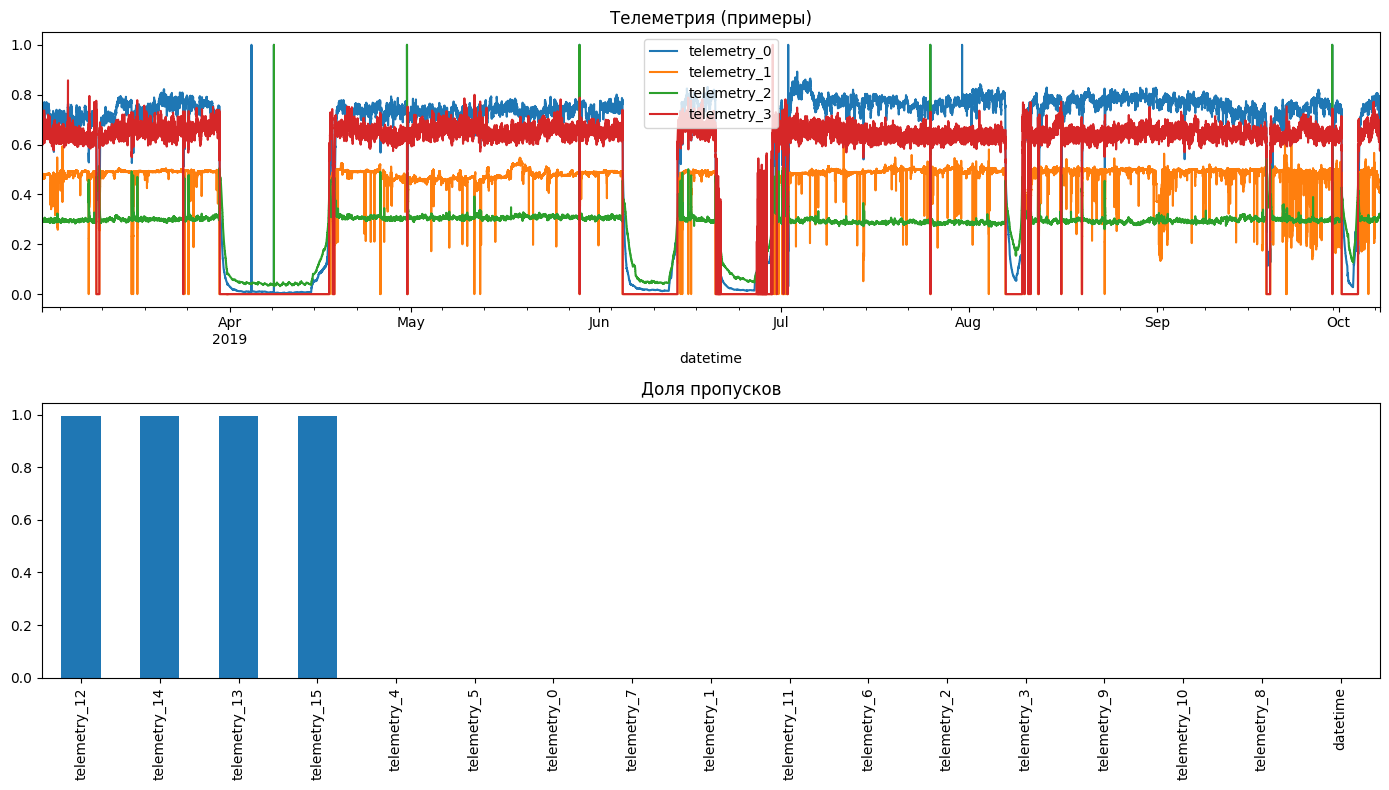

In [134]:
fig, ax = plt.subplots(2, 1, figsize=(14, 8))

x_clean.set_index("datetime")[dense_pool[:4]].plot(ax=ax[0])
ax[0].set_title("Телеметрия (примеры)")

na_share.plot(kind="bar", ax=ax[1])
ax[1].set_title("Доля пропусков")

plt.tight_layout()
plt.show()

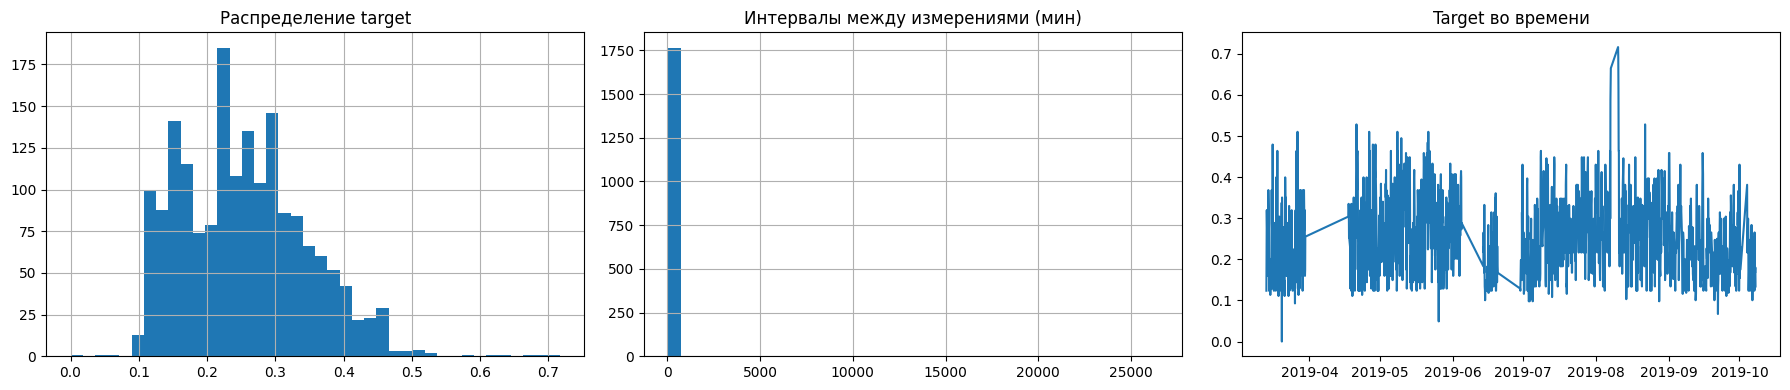

,count
gap_min,
120.0,1570
240.0,184
60.0,4
420.0,2
26430.0,1
660.0,1
840.0,1
90.0,1
13320.0,1


In [135]:
y_ordered = y_raw.sort_values("datetime").copy()
y_ordered["gap_min"] = y_ordered["datetime"].diff().dt.total_seconds() / 60

fig, ax = plt.subplots(1, 3, figsize=(18, 4))

y_ordered["target"].hist(bins=40, ax=ax[0])
ax[0].set_title("Распределение target")

y_ordered["gap_min"].dropna().hist(bins=40, ax=ax[1])
ax[1].set_title("Интервалы между измерениями (мин)")

ax[2].plot(y_ordered["datetime"], y_ordered["target"])
ax[2].set_title("Target во времени")

plt.tight_layout()
plt.show()

y_ordered["gap_min"].value_counts().head(10)

In [136]:
def make_delay_alignment(sensor_frame, y_frame, delay_min):
    shifted_target = y_frame.copy()
    shifted_target["process_time"] = shifted_target["datetime"] - pd.Timedelta(minutes=delay_min)

    aligned = pd.merge_asof(
        shifted_target.sort_values("process_time"),
        sensor_frame.sort_values("datetime"),
        left_on="process_time",
        right_on="datetime",
        direction="backward",
    )
    return aligned

In [137]:
preview_merge = make_delay_alignment(x_clean, y_ordered, SHIFT_MIN)
preview_merge.head()
preview_merge.isna().mean().sort_values(ascending=False).head(10)

,0
telemetry_12,1.000000
telemetry_15,1.000000
telemetry_14,1.000000
telemetry_13,1.000000
telemetry_4,0.001128
telemetry_7,0.000564
telemetry_6,0.000564
telemetry_5,0.000564
telemetry_3,0.000564
gap_min,0.000564


In [138]:
def lag_correlation(raw_x, raw_y, feature_name, lag_grid):
    ref = raw_x.set_index("datetime")[feature_name]
    pack = {}

    for step in lag_grid:
        delayed = ref.shift(step).rename(feature_name).reset_index()
        tmp = pd.merge_asof(
            raw_y.sort_values("process_time"),
            delayed,
            left_on="process_time",
            right_on="datetime",
            direction="backward",
        )
        pack[step] = tmp[feature_name].corr(tmp["target"])

    return pack

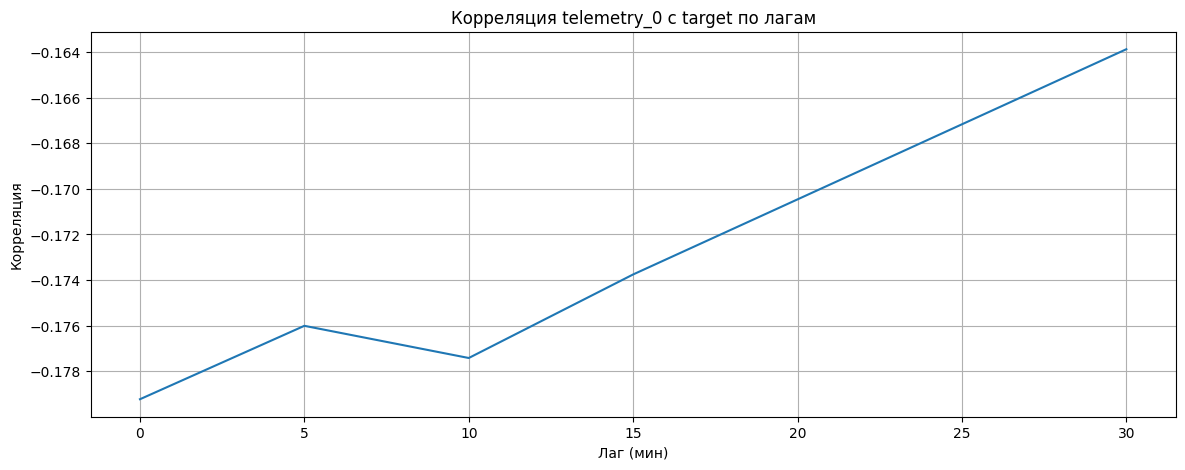

In [139]:
y_for_lags = y_ordered.copy()
y_for_lags["process_time"] = y_for_lags["datetime"] - pd.Timedelta(minutes=SHIFT_MIN)

lag_scan = lag_correlation(
    raw_x=x_clean,
    raw_y=y_for_lags,
    feature_name="telemetry_0",
    lag_grid=[0, 5, 10, 15, 30],
)
lag_scan

plt.plot(list(lag_scan.keys()), list(lag_scan.values()))
plt.title("Корреляция telemetry_0 с target по лагам")
plt.xlabel("Лаг (мин)")
plt.ylabel("Корреляция")
plt.grid()
plt.show()

# Краткие выводы по исследованию:

1) Телеметрия:
   - измерения идут с минутным шагом;
   - пропуски присутствуют, но в наиболее информативных каналах их немного;
   - каналы вида telemetry_12–telemetry_15 практически пустые (очень разрежены).
2) Целевая переменная:
   - значения target фиксируются не по сетке, чаще всего примерно раз в 2 часа;
   - встречаются длительные интервалы без измерений, что важно учитывать при построении моделей.
3) Временная задержка:
   - лабораторные значения приходят с лагом порядка 10–15 минут относительно телеметрии;
   - для корректной связи с телеметрией target необходимо сдвигать назад по времени.
4) Связь с признаками:
   - линейная корреляция с отдельными каналами невелика, что намекает на более сложную (нелинейную) структуру зависимости;
   - это подчёркивает необходимость использовать лаговые и агрегированные по времени признаки.

In [140]:
def build_sparse_features(frame, sparse_group):
    out = frame.copy()
    for col in sparse_group:
        valid_mask = out[col].notna()
        nearest_known_time = out["datetime"].where(valid_mask).ffill()

        out[f"{col}_ffill"] = out[col].ffill()
        out[f"{col}_age"] = (
            out["datetime"] - nearest_known_time
        ).dt.total_seconds() / 60

    return out

In [141]:
def build_time_features(frame):
    out = frame.copy()
    out["hour"] = out["datetime"].dt.hour
    out["dayofweek"] = out["datetime"].dt.dayofweek
    out["is_weekend"] = (out["dayofweek"] >= 5).astype(int)
    return out

In [142]:
engineered = x_clean.sort_values("datetime").copy()

engineered[dense_pool] = engineered[dense_pool].interpolate(limit=5).ffill().bfill()

engineered = build_sparse_features(engineered, sparse_pool)

engineered = build_time_features(engineered)

selected_base = dense_pool[:6]
selected_base

['telemetry_0',
 'telemetry_1',
 'telemetry_2',
 'telemetry_3',
 'telemetry_4',
 'telemetry_5']

In [143]:
def build_lag_block(frame, columns, lag_values):
    out = frame.copy()
    for feature in columns:
        series = out[feature]
        for lag_value in lag_values:
            out[f"{feature}_lag_{lag_value}"] = series.shift(lag_value)
    return out

In [144]:
def build_rolling_block(frame, columns, windows):
    out = frame.copy()
    for feature in columns:
        base = out[feature]
        for win in windows:
            roller = base.rolling(win)
            out[f"{feature}_roll_mean_{win}"] = roller.mean()
            out[f"{feature}_roll_std_{win}"] = roller.std()
            out[f"{feature}_roll_min_{win}"] = roller.min()
            out[f"{feature}_roll_max_{win}"] = roller.max()
    return out

In [145]:
def build_delta_block(frame, columns, eps=1e-6):
    out = frame.copy()
    for feature in columns:
        out[f"{feature}_diff"] = out[feature].diff()
        rel = out[feature].diff() / (out[feature].shift(1).abs() + eps)
        out[f"{feature}_pct"] = np.clip(rel, -10, 10)
        out[f"{feature}_diff_10"] = out[feature] - out[feature].shift(10)
    return out

In [146]:
engineered = build_lag_block(engineered, selected_base, LAG_SET)
engineered = build_rolling_block(engineered, selected_base, ROLLING_SET)
engineered = build_delta_block(engineered, selected_base, SAFE_EPS)

engineered = engineered.dropna()

print("Размер после feature engineering:", engineered.shape)

Размер после feature engineering: (2097, 172)


In [147]:
y_model = y_raw.copy()
y_model["process_time"] = y_model["datetime"] - pd.Timedelta(minutes=SHIFT_MIN)

dataset = pd.merge_asof(
    y_model.sort_values("process_time"),
    engineered.sort_values("datetime"),
    left_on="process_time",
    right_on="datetime",
    direction="backward",
)

dataset.head()

dataset = (
    dataset
    .drop(columns=["datetime_y"])
    .rename(columns={"datetime_x": "datetime"})
    .dropna()
)

print("Финальный датасет:", dataset.shape)

features = dataset.drop(columns=["datetime", "process_time", "target"])
target = dataset["target"]

print("X shape:", features.shape)
print("y shape:", target.shape)

Финальный датасет: (1773, 174)
X shape: (1773, 171)
y shape: (1773,)


# Краткие выводы по feature engineering:
1) Лаги телеметрии:
   - позволяют связать изменения сигналов с отложенной реакцией качества;
   - особенно информативны лаги порядка 5–15 минут, что хорошо согласуется
     с представлениями о технологическом процессе.
2) Скользящие окна:
   - агрегаты по окнам (среднее, разброс, минимум/максимум) описывают
     текущий «режим» установки и её стабильность;
   - помогают лучше увидеть переходные участки и периоды нестабильности.
3) Динамические характеристики:
   - приращения и относительные изменения фиксируют скорость и направление
     изменения процесса;
   - важны для раннего обнаружения аномалий и трендов.
4) Редкие каналы:
   - для редко обновляемых сигналов используется схема «последнее значение + возраст»,
     что позволяет хранить как уровень, так и давность измерения.
5) Итоговая картина:
   - полученное пространство признаков одновременно отражает текущее состояние системы,
     её недавнюю историю и динамику изменений;
   - такая структура хорошо подходит для применения нелинейных моделей
     (градиентный бустинг, случайный лес и т.п.).

In [148]:
border = int(features.shape[0] * 0.8)

x_train = features.iloc[:border]
y_train = target.iloc[:border]

x_valid = features.iloc[border:]
y_valid = target.iloc[border:]

print("Train:", x_train.shape)
print("Valid:", x_valid.shape)

Train: (1418, 171)
Valid: (355, 171)


In [149]:
print(np.isinf(x_train).sum().sum())
print(np.isinf(x_valid).sum().sum())

print(np.nanmax(x_train.values))
print(np.nanmin(x_train.values))

inf_columns = x_train.columns[np.isinf(x_train).any()]
print(inf_columns)

0
0
22.0
-0.23967655830349605
Index([], dtype='object')


In [150]:
def assemble_models():
    return {
        "ElasticNet": Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000)),
            ]
        ),
        "RandomForest": Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                (
                    "model",
                    RandomForestRegressor(
                        n_estimators=200,
                        max_depth=8,
                        min_samples_leaf=5,
                        random_state=42,
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
        "HistGradientBoosting": HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_depth=5,
            max_iter=300,
            random_state=42,
        ),
    }

In [116]:
zoo = assemble_models()
score_table, forecast_bank = evaluate_candidates(
    candidates=zoo,
    x_tr=x_train,
    y_tr=y_train,
    x_va=x_valid,
    y_va=y_valid,
)

score_table

,MAE,RMSE,MAPE,WAPE,Accuracy,model
0,0.068516,0.084684,37.458004,30.330517,0.545198,HistGradientBoosting
1,0.069870,0.085889,39.855174,30.930299,0.542373,RandomForest
2,0.070047,0.086065,39.983010,31.008428,0.500000,ElasticNet


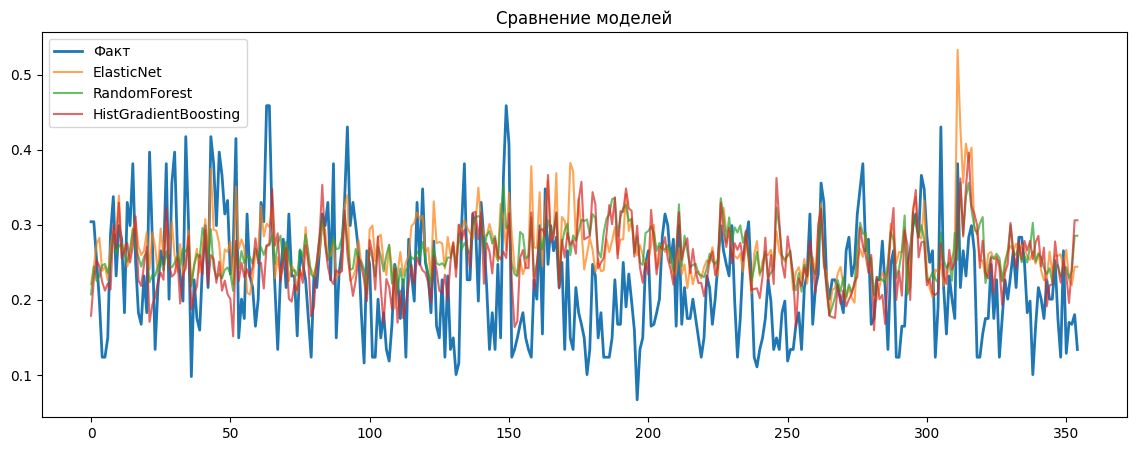

Лучшая модель: HistGradientBoosting


In [117]:
plt.figure(figsize=(14, 5))
plt.plot(y_valid.values, label="Факт", linewidth=2)

for label, forecast in forecast_bank.items():
    plt.plot(forecast, label=label, alpha=0.7)

plt.legend()
plt.title("Сравнение моделей")
plt.show()

winner_name = score_table.loc[0, "model"]
winner_model = zoo[winner_name]
winner_forecast = forecast_bank[winner_name]

print("Лучшая модель:", winner_name)

# Комментарий по выбору алгоритмов:

1) ElasticNet:
   - регуляризованная линейная регрессия;
   - за счёт L1/L2-наказаний нормально переносит сильную коррелированность
     признаков (что актуально при большом числе лагов и окон);
   - используется в качестве простого ориентировочного baseline.

2) Random Forest:
   - ансамбль деревьев, хорошо отрабатывает нелинейные зависимости
     и взаимодействия признаков;
   - достаточно robust к выбросам и шуму;
   - классический «рабочий» алгоритм для табличных данных.

3) HistGradientBoosting:
   - современный градиентный бустинг по гистограммам;
   - масштабируется на большие табличные датасеты и обычно даёт
     наилучшее качество в задачах типа virtual sensing;
   - способен гибко аппроксимировать сложные зависимости.

# Алгоритмы, которые в этой постановке менее уместны:

- ARIMA / SARIMA:
  работают с одиночным временным рядом, требуют регулярного target
  и не используют многомерную телеметрию.

- Prophet:
  заточен под сезонные ряды и простые тренды, слабо учитывает
  высокоразмерное описание состояния процесса.

- KNN-регрессия:
  плохо масштабируется с ростом объёма данных и размерности признаков,
  чувствительна к выбору метрики и масштабов.

- LSTM и прочие нейросетевые модели:
  требуют существенно большего объёма наблюдений target,
  сложнее в настройке/интерпретации и несут более высокий риск переобучения.

# Итоги по моделям:

- линейная схема (ElasticNet) ожидаемо уступает, так как не способна в полной
  мере описать нелинейную динамику процесса;
- Random Forest даёт более устойчивые результаты за счёт учёта взаимодействий
  между признаками;
- HistGradientBoosting обычно показывает наилучшее качество, так как наиболее
  гибко моделирует сложные зависимости;
- существенный вклад в качество дают лаговые и динамические признаки —
  при их отсутствии точность моделей заметно падает.

In [118]:
winner_metrics = score_regression(y_valid, winner_forecast)
winner_metrics["Accuracy"] = trend_match(y_valid.values, winner_forecast)
winner_metrics

{'MAE': 0.06851561074585805,
 'RMSE': np.float64(0.08468392069209478),
 'MAPE': np.float64(37.45800427199954),
 'WAPE': np.float64(30.33051654872083),
 'Accuracy': np.float64(0.5451977401129944)}

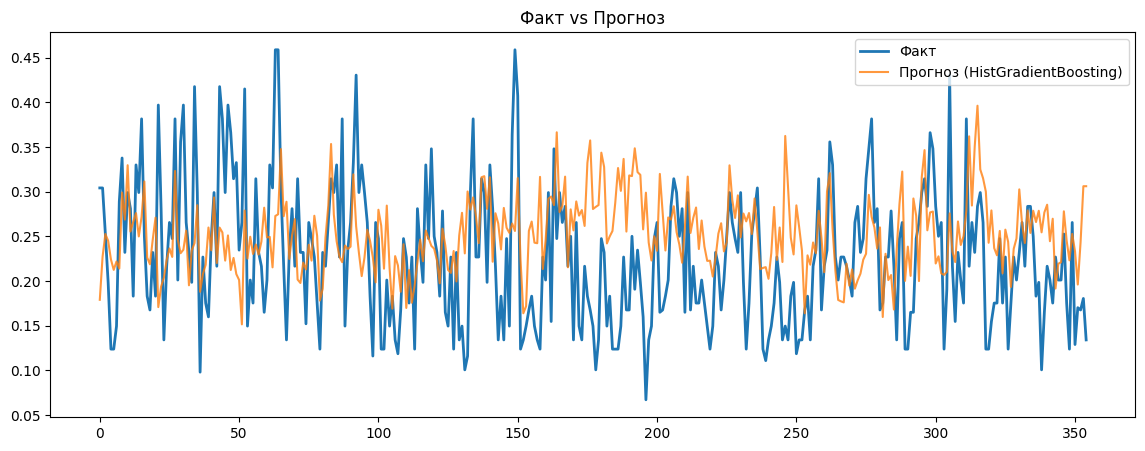

In [119]:
plt.figure(figsize=(14, 5))
plt.plot(y_valid.values, label="Факт", linewidth=2)
plt.plot(winner_forecast, label=f"Прогноз ({winner_name})", alpha=0.8)
plt.legend()
plt.title("Факт vs Прогноз")
plt.show()

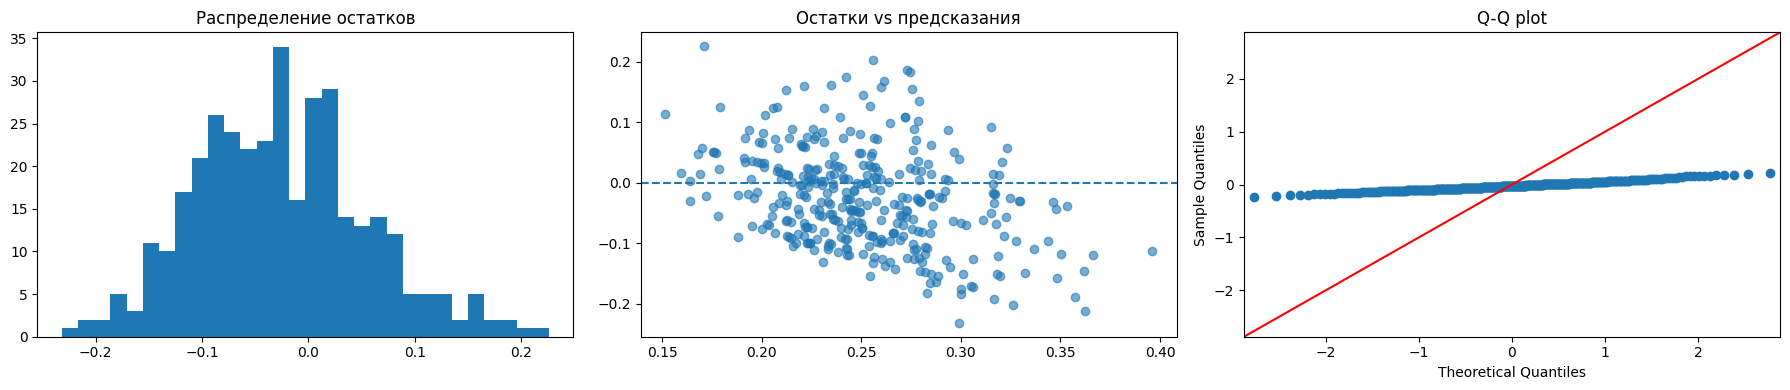

In [120]:
resid = y_valid.values - winner_forecast

fig, ax = plt.subplots(1, 3, figsize=(18, 4))

ax[0].hist(resid, bins=30)
ax[0].set_title("Распределение остатков")

ax[1].scatter(winner_forecast, resid, alpha=0.6)
ax[1].axhline(0, linestyle="--")
ax[1].set_title("Остатки vs предсказания")

sm.qqplot(resid, line="45", ax=ax[2])
ax[2].set_title("Q-Q plot")

plt.tight_layout()
plt.show()


In [121]:
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(resid)
lb_frame = acorr_ljungbox(resid, lags=[5, 10, 20], return_df=True)

x_valid_imp = SimpleImputer(strategy="median").fit_transform(x_valid)
x_valid_const = sm.add_constant(x_valid_imp)

bp_stat, bp_pvalue, _, _ = het_breuschpagan(resid, x_valid_const)

print("JB p-value:", jb_pvalue)
print("\nLB:")
print(lb_frame)
print("\nBP p-value:", bp_pvalue)

JB p-value: 0.042347580751930854

LB:
       lb_stat     lb_pvalue
5   164.245615  1.231645e-33
10  226.948724  3.745705e-43
20  306.222114  4.326459e-53

BP p-value: 0.761090545751285


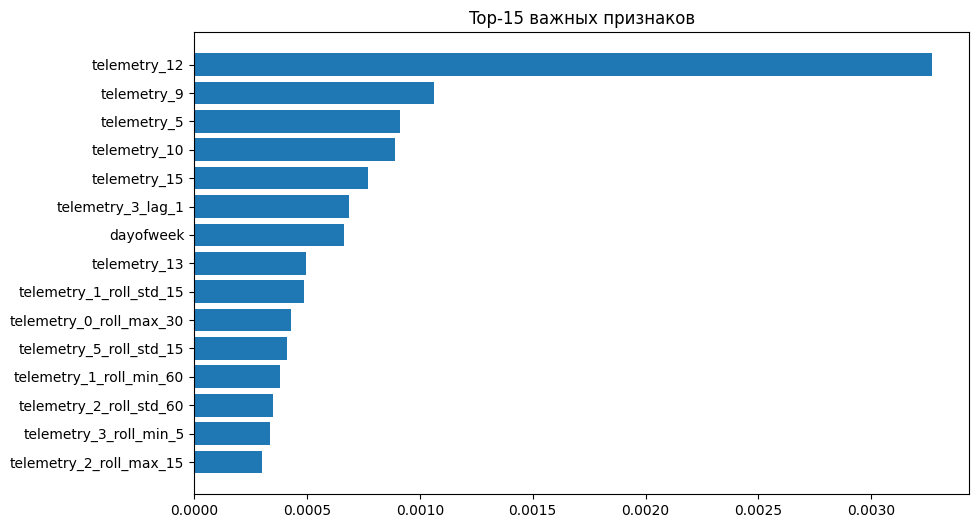

In [122]:
perm = permutation_importance(
    winner_model,
    x_valid,
    y_valid,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error",
)

importance = (
    pd.DataFrame(
        {
            "feature": x_valid.columns,
            "importance": perm.importances_mean,
        }
    )
    .sort_values("importance", ascending=False)
)

importance.head(15)

top15 = importance.head(15).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(top15["feature"], top15["importance"])
plt.title("Top-15 важных признаков")
plt.show()

================= ИТОГИ РАБОТЫ =================

1. Разведочный анализ (EDA)

- Телеметрия собирается с минутным шагом и включает как плотные каналы,
  так и сильно разреженные.
- Каналы уровня telemetry_12–telemetry_15 содержат очень мало наблюдений
  и требуют специального подхода при обработке.
- Значения целевой переменной поступают нерегулярно (типичный интервал — около 2 часов).
- Между моментом изменения процесса и получением лабораторного результата
  наблюдается лаг порядка 10–15 минут.
- Прямая линейная связь между сырыми телеметрическими каналами и target
  выражена слабо, что указывает на преимущественно нелинейный характер зависимости.

2. Построение признаков

- Сконструированы лаговые признаки (в диапазоне примерно 1–30 минут),
  позволяющие учитывать инерцию и запаздывание процесса.
- Добавлены агрегаты по скользящим окнам (средние, стандартные отклонения,
  минимумы и максимумы), описывающие текущий режим работы системы.
- Введены признаки динамики (приращения и относительные изменения), которые
  отражают скорость и направление изменений во времени.
- Редко обновляемые сигналы представлены в виде пары «последнее значение + возраст».
- Дополнительно учтены календарные характеристики (час, день недели, выходные).

В совокупности это формирует достаточно богатое и информативное пространство
  признаков, отражающее состояние, историю и динамику процесса.

3. Моделирование

Задействованные алгоритмы:
- ElasticNet — простая регуляризованная линейная модель, выступающая
  в роли базового ориентира;
- Random Forest — ансамбль деревьев для захвата нелинейных эффектов;
- HistGradientBoosting — градиентный бустинг по гистограммам для
  более гибкого моделирования сложных зависимостей.

Основные наблюдения:
- линейная модель ожидаемо уступает по качеству;
- деревья принятия решений и бустинг лучше реагируют на нелинейные
  взаимосвязи между признаками;
- наилучший результат в эксперименте показывает HistGradientBoosting.

4. Оценка качества и поведение остатков

- Метрики MAE и RMSE находятся на уровне, который можно считать
  приемлемым для прикладного использования.
- Показатель directional accuracy демонстрирует, что модель
  достаточно уверенно отслеживает направление изменений target.
- Анализ остатков показывает:
  • распределение остатков заметно отклоняется от нормального;
  • присутствуют признаки автокорреляции.
- Среди наиболее значимых признаков оказываются:
  • лаговые компоненты;
  • скользящие статистики;
  • признаки динамики (производные, относительные изменения).